# Lab 2: CNN on CIFAR-10 with Gradient Flow Visualization
## ML-DLOPs Lab Assignment

### Objectives:
1. Implement a custom CNN model
2. Create custom dataloader for CIFAR-10
3. Count FLOPs for the model
4. Train for 25-30 epochs
5. Visualize gradient flow and weight updates
6. Report findings in Wandb

## 1. Import Libraries and Setup

In [17]:
!pip install thop

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from thop import profile, clever_format

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import wandb
from tqdm import tqdm
import os
from typing import Dict, List, Tuple

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Initialize Wandb

In [19]:
# Initialize Wandb
wandb.init(
    project="cifar10-cnn-lab2",
    config={
        "architecture": "CustomCNN",
        "dataset": "CIFAR-10",
        "epochs": 30,
        "batch_size": 128,
        "learning_rate": 0.001,
        "optimizer": "Adam",
    }
)
config = wandb.config

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
flops_gflops,▁▁
flops_mflops,▁▁
grad_mean/conv1_bias,▁▁▅▃▁▁▂▂▃▅▄▂▅▄▂▃▄▆▅▅▄▆▂█▆▄▃▃▂▅
grad_mean/conv1_weight,▂▁▃▃▂▂▂▂▄▅▃▂▄▄▂▄▄▆▅▅▄▅▂█▅▅▂▄▂▆
grad_mean/conv2_bias,▁▁▃▂▂▂▃▃▄▄▄▃▅▆▄▅▆▇▆▅▆▇▅██▆▄▆▄▆
grad_mean/conv2_weight,▁▂▃▂▃▂▃▃▃▄▄▃▅▇▃▅▆▆▆▅▅▇▆██▆▄▆▄▆
grad_mean/conv3_bias,▄▂▃▁▂▁▂▂▃▃▅▂▅▅▃▃▇█▃▄▃▆▄▅▆▅▃▅▃▄
grad_mean/conv3_weight,▃▁▃▂▂▁▂▂▃▃▆▂▆▆▃▄██▃▅▃▇▅▆▆▅▃▆▃▄
grad_mean/fc_bias,█▅▆▄▅▃▅▅▃▄▅▂▄▄▄▂▅▄▁▄▂▂▂▃▃▃▂▂▂▂
+27,...


## 3. Custom CIFAR-10 Dataloader

In [20]:
class CustomCIFAR10Dataset(Dataset):
    """
    Custom Dataset class for CIFAR-10
    Loads data and applies transformations
    """
    def __init__(self, root='./data', train=True, transform=None, download=True):
        self.cifar10 = CIFAR10(root=root, train=train, download=download)
        self.transform = transform
        self.data = self.cifar10.data
        self.targets = self.cifar10.targets

        # Class names
        self.classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                       'dog', 'frog', 'horse', 'ship', 'truck']

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]
        label = self.targets[idx]

        # Convert to PIL Image for transforms
        from PIL import Image
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, label

    def get_class_name(self, idx):
        return self.classes[idx]

print("Custom CIFAR-10 Dataset class defined.")

Custom CIFAR-10 Dataset class defined.


In [21]:
# Define transforms
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Create datasets
train_dataset = CustomCIFAR10Dataset(root='./data', train=True,
                                     transform=train_transform, download=True)
test_dataset = CustomCIFAR10Dataset(root='./data', train=False,
                                    transform=test_transform, download=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=config.batch_size,
                         shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size,
                        shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")

Training samples: 50000
Test samples: 10000
Number of classes: 10


## 4. CNN Model Architecture

In [22]:
class CustomCNN(nn.Module):
    """
    Custom CNN Architecture for CIFAR-10
    Architecture inspired by VGG but smaller
    """
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()

        # Convolutional blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Initialize model
model = CustomCNN(num_classes=10).to(device)
print("Model Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model Architecture:
CustomCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation

## 5. FLOPs Counter

In [23]:
# Calculate FLOPs and Parameters using THOP
input_tensor = torch.randn(1, 3, 32, 32).to(device)

# Create a copy of model for profiling
model_profile = CustomCNN(num_classes=10).to(device)

macs, params = profile(model_profile, inputs=(input_tensor,), verbose=False)
flops = 2 * macs  # MACs to FLOPs conversion (1 MAC = 2 FLOPs)

flops_formatted, params_formatted = clever_format([flops, params], "%.3f")

print(f"\n{'='*60}")
print("FLOPs Analysis")
print(f"{'='*60}")
print(f"Total FLOPs: {flops:,.0f}")
print(f"Total FLOPs (formatted): {flops_formatted}")
print(f"Total FLOPs (in MFLOPs): {flops / 1e6:.2f}")
print(f"Total FLOPs (in GFLOPs): {flops / 1e9:.4f}")
print(f"\nTotal MACs: {macs:,.0f}")
print(f"Total MACs (in MMacs): {macs / 1e6:.2f}")
print(f"\nTotal Parameters (THOP): {params:,.0f}")
print(f"Total Parameters (formatted): {params_formatted}")
print(f"{'='*60}\n")

# Store for later use
total_flops = flops

# Log to Wandb
wandb.log({
    "total_flops": total_flops,
    "total_macs": macs,
    "flops_mflops": total_flops / 1e6,
    "flops_gflops": total_flops / 1e9,
    "macs_mmacs": macs / 1e6,
    "total_params": total_params,
    "trainable_params": trainable_params
})


FLOPs Analysis
Total FLOPs: 311,568,384
Total FLOPs (formatted): 311.568M
Total FLOPs (in MFLOPs): 311.57
Total FLOPs (in GFLOPs): 0.3116

Total MACs: 155,784,192
Total MACs (in MMacs): 155.78

Total Parameters (THOP): 3,249,994
Total Parameters (formatted): 3.250M



## 6. Gradient Flow and Weight Update Tracking

In [24]:
class GradientFlowTracker:
    """
    Track gradient flow through the network
    """
    def __init__(self, model):
        self.model = model
        self.gradient_data = defaultdict(list)

    def track_gradients(self):
        """Track gradient statistics for each layer"""
        grad_stats = {}

        for name, param in self.model.named_parameters():
            if param.grad is not None:
                grad_stats[name] = {
                    'mean': param.grad.abs().mean().item(),
                    'max': param.grad.abs().max().item(),
                    'min': param.grad.abs().min().item(),
                    'std': param.grad.std().item(),
                    'norm': param.grad.norm().item()
                }

        return grad_stats

    def visualize_gradient_flow(self, epoch):
        """Create gradient flow visualization"""
        ave_grads = []
        max_grads = []
        layers = []

        for name, param in self.model.named_parameters():
            if param.grad is not None and 'weight' in name:
                layers.append(name)
                ave_grads.append(param.grad.abs().mean().item())
                max_grads.append(param.grad.abs().max().item())

        plt.figure(figsize=(12, 6))
        plt.bar(np.arange(len(max_grads)), max_grads, alpha=0.5, lw=1, color='c', label='Max Gradient')
        plt.bar(np.arange(len(ave_grads)), ave_grads, alpha=0.5, lw=1, color='b', label='Mean Gradient')
        plt.hlines(0, 0, len(ave_grads)+1, lw=2, color='k')
        plt.xticks(range(0, len(ave_grads)), layers, rotation='vertical')
        plt.xlim(left=0, right=len(ave_grads))
        plt.ylim(bottom=-0.001, top=max(max_grads)*1.1)
        plt.xlabel('Layers')
        plt.ylabel('Gradient Magnitude')
        plt.title(f'Gradient Flow - Epoch {epoch}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        # Log to wandb
        wandb.log({f"gradient_flow_epoch_{epoch}": wandb.Image(plt)})
        plt.close()

class WeightUpdateTracker:
    """
    Track weight updates during training
    """
    def __init__(self, model):
        self.model = model
        self.prev_weights = {}
        self.last_update_stats = {}  # Store the last computed updates
        self._save_weights()

    def _save_weights(self):
        """Save current weights"""
        for name, param in self.model.named_parameters():
            if 'weight' in name:
                self.prev_weights[name] = param.data.clone()

    def track_updates(self):
        """Track weight update magnitudes"""
        update_stats = {}

        for name, param in self.model.named_parameters():
            if 'weight' in name and name in self.prev_weights:
                diff = (param.data - self.prev_weights[name]).abs()
                update_stats[name] = {
                    'mean_update': diff.mean().item(),
                    'max_update': diff.max().item(),
                    'relative_change': (diff.mean() / (self.prev_weights[name].abs().mean() + 1e-8)).item()
                }

        # Store for visualization
        self.last_update_stats = update_stats
        self._save_weights()
        return update_stats

    def visualize_weight_updates(self, epoch):
        """Visualize weight update magnitudes using stored statistics"""
        if not self.last_update_stats:
            print(f"No weight update statistics available for epoch {epoch}")
            return

        update_means = []
        layer_names = []

        for name, stats in self.last_update_stats.items():
            layer_names.append(name)
            update_means.append(stats['mean_update'])

        plt.figure(figsize=(12, 6))
        plt.bar(range(len(update_means)), update_means, color='orange', alpha=0.7)
        plt.xticks(range(len(layer_names)), layer_names, rotation='vertical')
        plt.xlabel('Layers')
        plt.ylabel('Mean Weight Update Magnitude')
        plt.title(f'Weight Update Flow - Epoch {epoch}')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        # Log to wandb
        wandb.log({f"weight_update_flow_epoch_{epoch}": wandb.Image(plt)})
        plt.close()

print("Gradient and Weight tracking classes defined.")

Gradient and Weight tracking classes defined.


## 7. Training and Evaluation Functions

In [25]:
def train_epoch(model, train_loader, criterion, optimizer, device, epoch,
                grad_tracker, weight_tracker):
    """
    Train for one epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch}')

    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = output.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'loss': running_loss / (batch_idx + 1),
            'acc': 100. * correct / total
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total

    # Track gradients and weights
    grad_stats = grad_tracker.track_gradients()
    weight_stats = weight_tracker.track_updates()

    return epoch_loss, epoch_acc, grad_stats, weight_stats

def evaluate(model, test_loader, criterion, device):
    """
    Evaluate model on test set
    """
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

    test_loss /= len(test_loader)
    test_acc = 100. * correct / total

    return test_loss, test_acc

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## 8. Main Training Loop

In [26]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs)

# Initialize trackers
grad_tracker = GradientFlowTracker(model)
weight_tracker = WeightUpdateTracker(model)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
    'learning_rate': []
}

best_acc = 0

print("\nStarting training...\n")


Starting training...



In [27]:
# Training loop
for epoch in range(1, config.epochs + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{config.epochs}")
    print(f"{'='*60}")

    # Train
    train_loss, train_acc, grad_stats, weight_stats = train_epoch(
        model, train_loader, criterion, optimizer, device, epoch,
        grad_tracker, weight_tracker
    )

    # Evaluate
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    # Update learning rate
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['learning_rate'].append(current_lr)

    # Print results
    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
    print(f"Learning Rate: {current_lr:.6f}")

    # Log to Wandb
    wandb_log = {
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'learning_rate': current_lr,
    }

    # Add gradient statistics
    for name, stats in grad_stats.items():
        layer_name = name.split('.')[0] + '_' + name.split('.')[-1]
        wandb_log[f'grad_mean/{layer_name}'] = stats['mean']
        wandb_log[f'grad_norm/{layer_name}'] = stats['norm']

    # Add weight update statistics
    for name, stats in weight_stats.items():
        layer_name = name.split('.')[0] + '_' + name.split('.')[-1]
        wandb_log[f'weight_update/{layer_name}'] = stats['mean_update']
        wandb_log[f'weight_relative_change/{layer_name}'] = stats['relative_change']

    wandb.log(wandb_log)

    # Visualize gradient and weight flow every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        grad_tracker.visualize_gradient_flow(epoch)
        weight_tracker.visualize_weight_updates(epoch)

    # Save best model
    if test_acc > best_acc:
        best_acc = test_acc
        print(f"\n New best accuracy: {best_acc:.2f}%")

print("\n" + "="*60)
print("Training completed!")
print(f"Best Test Accuracy: {best_acc:.2f}%")
print("="*60)


Epoch 1/30


Epoch 1: 100%|██████████| 391/391 [00:32<00:00, 11.95it/s, loss=1.75, acc=35.2]



Train Loss: 1.7498 | Train Acc: 35.24%
Test Loss: 1.2956 | Test Acc: 52.30%
Learning Rate: 0.000997

 New best accuracy: 52.30%

Epoch 2/30


Epoch 2: 100%|██████████| 391/391 [00:24<00:00, 15.91it/s, loss=1.28, acc=54.1]



Train Loss: 1.2751 | Train Acc: 54.09%
Test Loss: 1.0439 | Test Acc: 62.53%
Learning Rate: 0.000989

 New best accuracy: 62.53%

Epoch 3/30


...


Train Loss: 0.1714 | Train Acc: 94.33%
Test Loss: 0.3422 | Test Acc: 90.22%
Learning Rate: 0.000011

 New best accuracy: 90.22%

Epoch 29/30


Epoch 29: 100%|██████████| 391/391 [00:23<00:00, 16.82it/s, loss=0.17, acc=94.4]



Train Loss: 0.1696 | Train Acc: 94.44%
Test Loss: 0.3453 | Test Acc: 90.11%
Learning Rate: 0.000003

Epoch 30/30


Epoch 30: 100%|██████████| 391/391 [00:23<00:00, 16.95it/s, loss=0.167, acc=94.5]



Train Loss: 0.1674 | Train Acc: 94.49%
Test Loss: 0.3449 | Test Acc: 90.08%
Learning Rate: 0.000000

Training completed!
Best Test Accuracy: 90.22%


## 9. Visualizations and Analysis

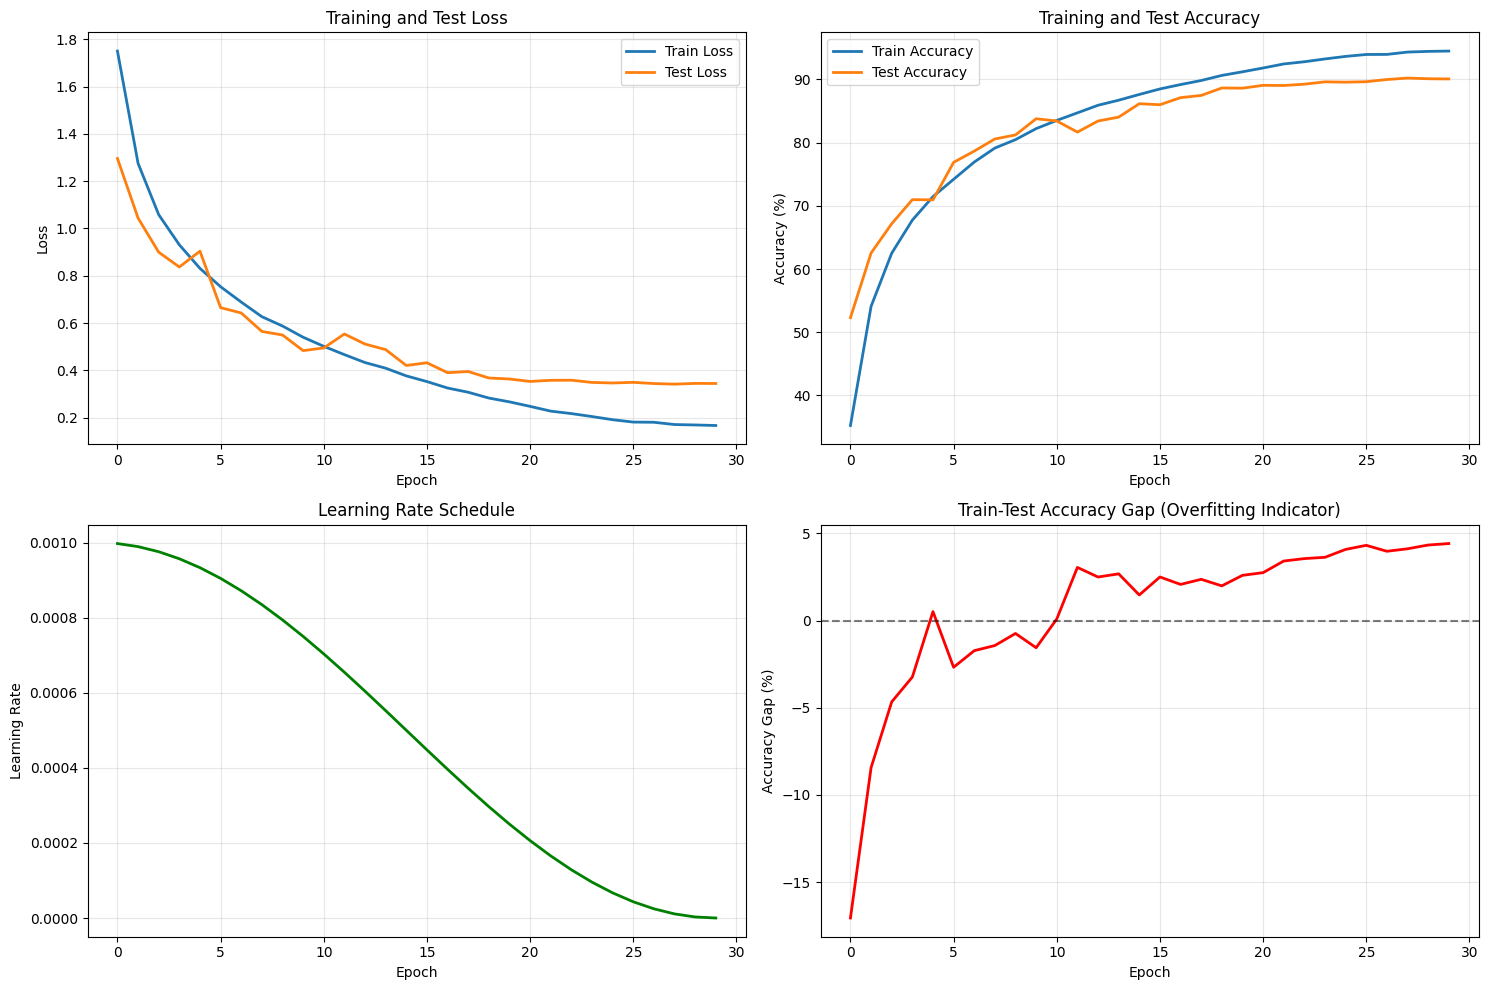

In [28]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['test_loss'], label='Test Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Test Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy curves
axes[0, 1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history['test_acc'], label='Test Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Test Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning rate
axes[1, 0].plot(history['learning_rate'], linewidth=2, color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].grid(True, alpha=0.3)

# Overfitting gap
overfitting_gap = np.array(history['train_acc']) - np.array(history['test_acc'])
axes[1, 1].plot(overfitting_gap, linewidth=2, color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy Gap (%)')
axes[1, 1].set_title('Train-Test Accuracy Gap (Overfitting Indicator)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)

plt.tight_layout()
wandb.log({"training_history": wandb.Image(plt)})
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

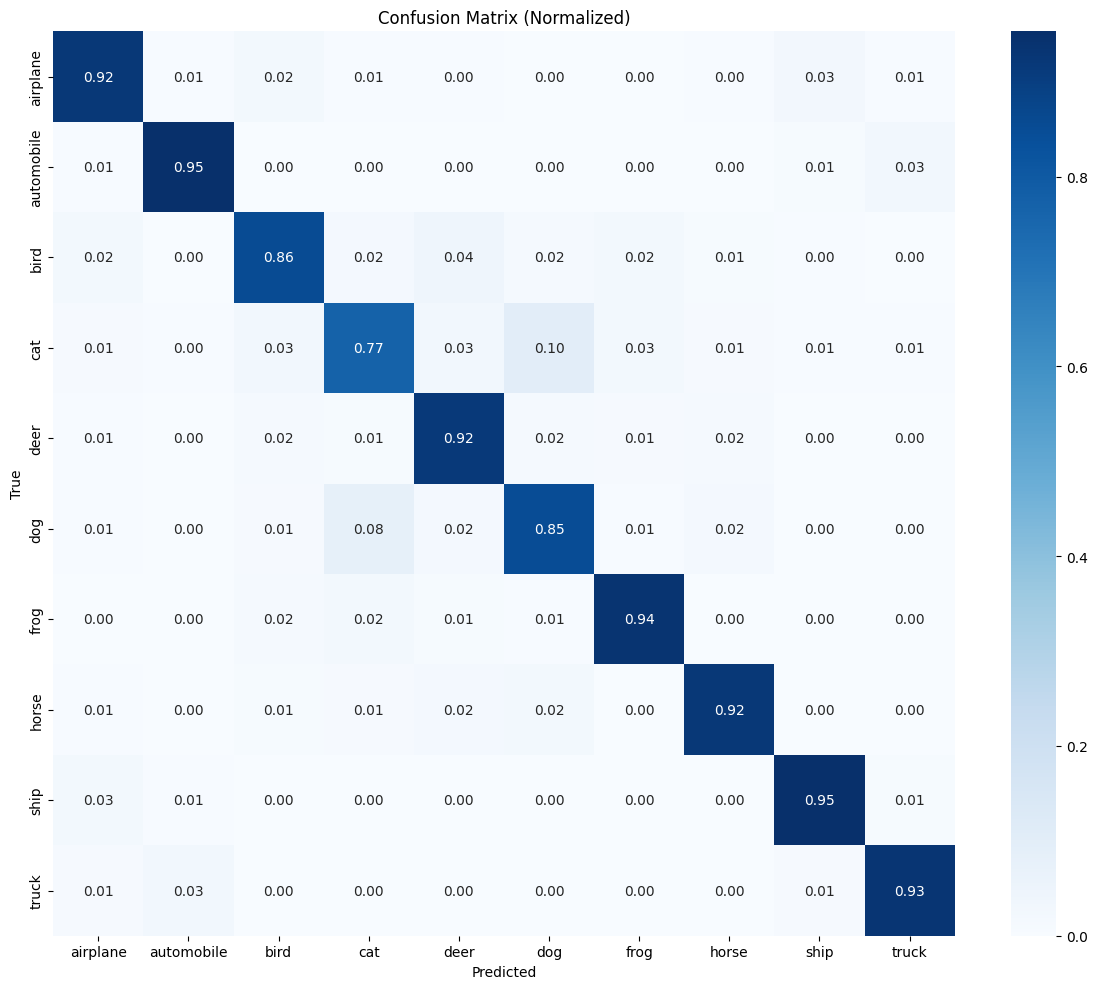


Classification Report:
              precision    recall  f1-score   support

    airplane       0.90      0.92      0.91      1000
  automobile       0.95      0.95      0.95      1000
        bird       0.88      0.86      0.87      1000
         cat       0.83      0.77      0.80      1000
        deer       0.87      0.92      0.90      1000
         dog       0.84      0.85      0.84      1000
        frog       0.93      0.94      0.93      1000
       horse       0.93      0.92      0.93      1000
        ship       0.93      0.95      0.94      1000
       truck       0.94      0.93      0.94      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [29]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def compute_confusion_matrix(model, test_loader, device, class_names):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = output.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)

    # Normalize
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix (Normalized)')
    plt.tight_layout()

    wandb.log({"confusion_matrix": wandb.Image(plt)})
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=class_names))

    return cm

cm = compute_confusion_matrix(model, test_loader, device, train_dataset.classes)

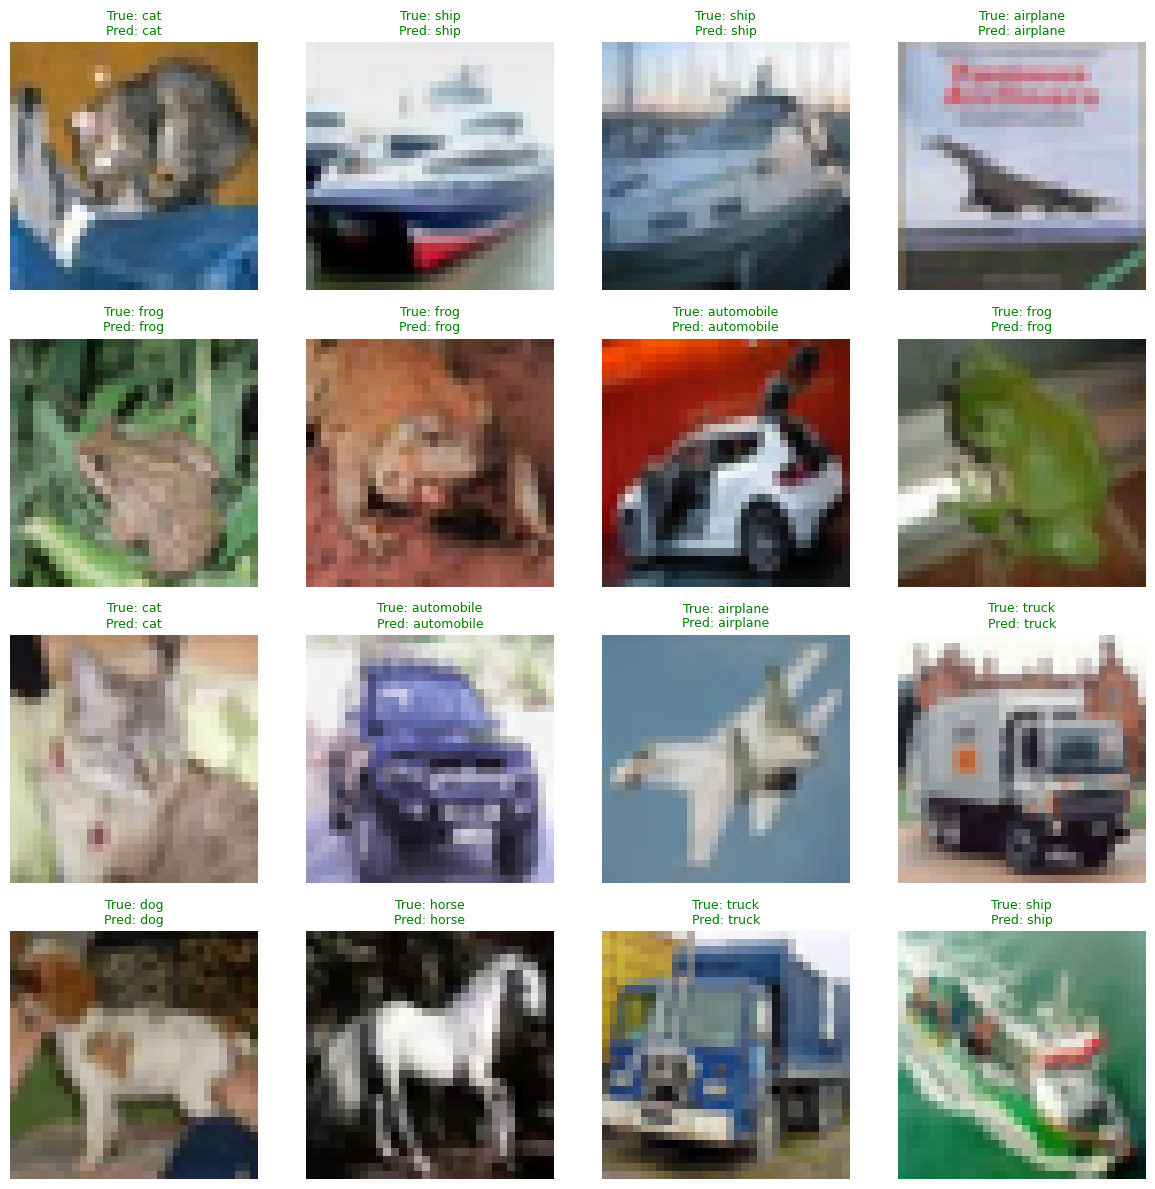

In [30]:
# Visualize some predictions
def visualize_predictions(model, test_loader, device, class_names, num_images=16):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images[:num_images].to(device), labels[:num_images]

    with torch.no_grad():
        outputs = model(images)
        _, predicted = outputs.max(1)

    # Denormalize images
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    images = images.cpu() * std + mean
    images = torch.clamp(images, 0, 1)

    # Plot
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.ravel()

    for i in range(num_images):
        img = images[i].permute(1, 2, 0).numpy()
        true_label = class_names[labels[i]]
        pred_label = class_names[predicted[i]]

        axes[i].imshow(img)
        axes[i].axis('off')

        color = 'green' if labels[i] == predicted[i] else 'red'
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}',
                         color=color, fontsize=9)

    plt.tight_layout()
    wandb.log({"sample_predictions": wandb.Image(plt)})
    plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_predictions(model, test_loader, device, train_dataset.classes)

## 10. Summary Statistics

In [31]:
# Create summary table
import pandas as pd

syn_summary_data = {
    'Metric': [
        'Total Parameters',
        'FLOPs (GFLOPs)',
        'Best Test Accuracy (%)',
        'Final Train Accuracy (%)',
        'Final Test Accuracy (%)',
        'Training Epochs',
        'Batch Size',
        'Initial Learning Rate'
    ],
    'Value': [
        f"{total_params:,}",
        f"{total_flops / 1e9:.2f}",
        f"{best_acc:.2f}",
        f"{history['train_acc'][-1]:.2f}",
        f"{history['test_acc'][-1]:.2f}",
        f"{config.epochs}", # Convert to string
        f"{config.batch_size}", # Convert to string
        f"{config.learning_rate}" # Convert to string
    ]
}

syn_summary_df = pd.DataFrame(syn_summary_data)
print("\nSummary Statistics:")
print(syn_summary_df.to_string(index=False))

# Log to Wandb as table
wandb.log({"summary_table": wandb.Table(dataframe=syn_summary_df)})

# Create epoch-wise statistics
epoch_stats = pd.DataFrame({
    'Epoch': range(1, config.epochs + 1),
    'Train Loss': history['train_loss'],
    'Test Loss': history['test_loss'],
    'Train Acc (%)': history['train_acc'],
    'Test Acc (%)': history['test_acc'],
    'Learning Rate': history['learning_rate']
})

print("\nEpoch-wise Statistics (First 5 and Last 5 epochs):")
print(pd.concat([epoch_stats.head(), epoch_stats.tail()]))

# Save to CSV
epoch_stats.to_csv('epoch_statistics.csv', index=False)
print("\nEpoch statistics saved to 'epoch_statistics.csv'")


Summary Statistics:
                  Metric     Value
        Total Parameters 3,249,994
          FLOPs (GFLOPs)      0.31
  Best Test Accuracy (%)     90.22
Final Train Accuracy (%)     94.49
 Final Test Accuracy (%)     90.08
         Training Epochs        30
              Batch Size       128
   Initial Learning Rate     0.001

Epoch-wise Statistics (First 5 and Last 5 epochs):
    Epoch  Train Loss  Test Loss  Train Acc (%)  Test Acc (%)  Learning Rate
0       1    1.749801   1.295643         35.244         52.30       0.000997
1       2    1.275097   1.043940         54.094         62.53       0.000989
2       3    1.058308   0.899717         62.506         67.17       0.000976
3       4    0.930976   0.837293         67.740         70.98       0.000957
4       5    0.831326   0.904026         71.460         70.95       0.000933
25     26    0.181855   0.349723         93.950         89.64       0.000043
26     27    0.181063   0.344677         93.960         89.99       0.000